# Heart Disease Prediction: EDA, Multi-Model ML Benchmarking, Tuning & Inference

This notebook performs comprehensive Exploratory Data Analysis (EDA), data cleaning, feature preprocessing, multi-model evaluation across 11 classifiers, hyperparameter optimization, and end-to-end patient 10-year Coronary Heart Disease (CHD) risk prediction using the Framingham Heart Study dataset.

## 1. Environment Setup & Library Imports

In [1]:
# Import core data analysis and visualization libraries
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Import scikit-learn preprocessing and validation modules
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

# Import machine learning classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Configure global environment display and plotting settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Dataset Loading & General Overview

In [2]:
# Load Framingham Heart Study dataset
df = pd.read_csv('framingham.csv')

# Print basic shape and column overview
print("Dataset Shape:", df.shape)
print("\nData Types and Missing Values Info:")
df.info()

Dataset Shape: (4240, 16)

Data Types and Missing Values Info:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float

In [3]:
# Display first 5 rows of dataset
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Analysis

In [5]:
# Compute target class distribution counts and percentages
target_counts = df['TenYearCHD'].value_counts()
target_pct = df['TenYearCHD'].value_counts(normalize=True) * 100

# Output target counts and proportions
print("Target Class Counts:\n", target_counts)
print("\nTarget Class Percentages (%):\n", target_pct.round(2))

Target Class Counts:
 TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Target Class Percentages (%):
 TenYearCHD
0    84.81
1    15.19
Name: proportion, dtype: float64


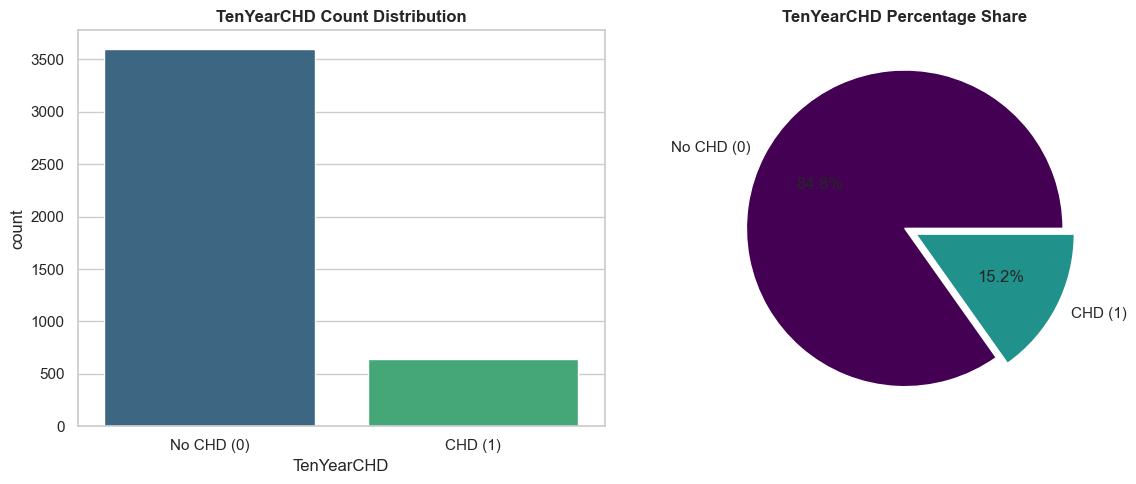

In [6]:
# Plot target variable distribution count plot and pie chart
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='TenYearCHD', hue='TenYearCHD', palette='viridis', legend=False, ax=ax[0])
ax[0].set_title('TenYearCHD Count Distribution', fontsize=12, fontweight='bold')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['No CHD (0)', 'CHD (1)'])

ax[1].pie(target_counts, labels=['No CHD (0)', 'CHD (1)'], autopct='%1.1f%%', colors=['#440154', '#21918c'], explode=(0, 0.08))
ax[1].set_title('TenYearCHD Percentage Share', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Continuous Numerical Features Distribution

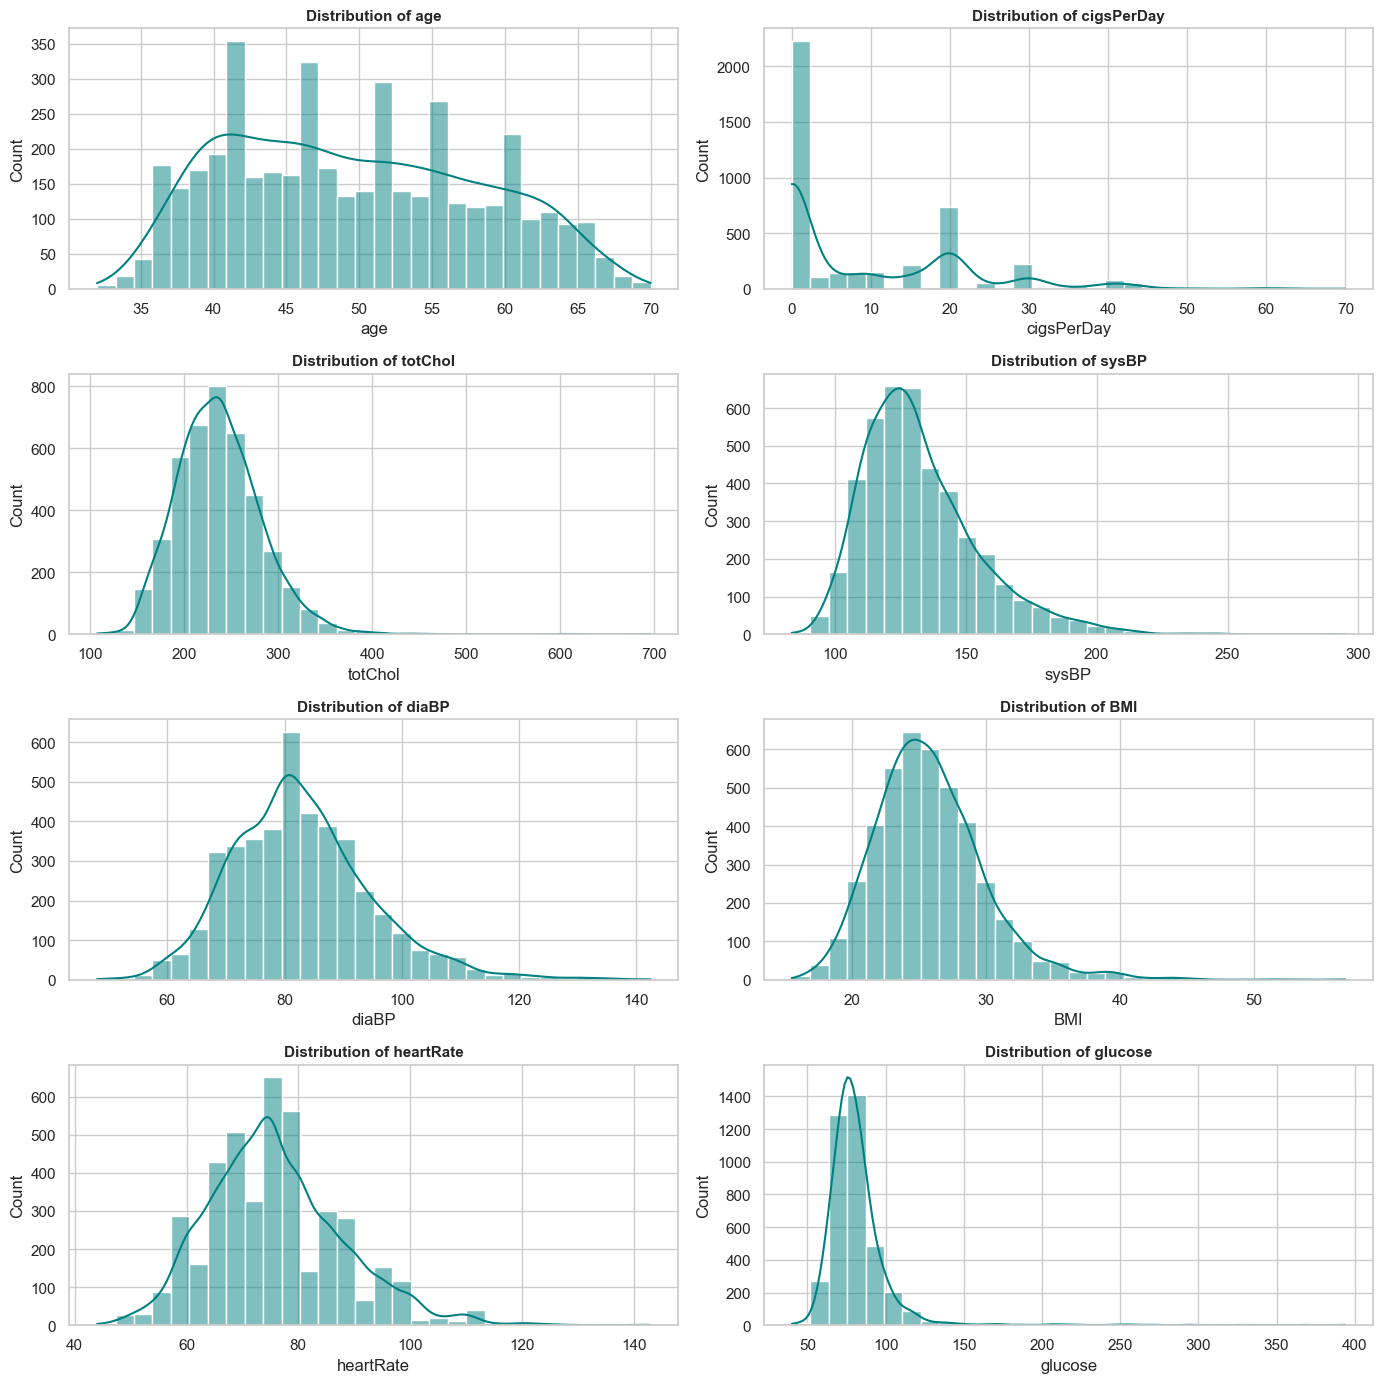

In [7]:
# Select continuous numerical columns for distribution plots
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# Plot histograms with KDE for continuous numerical variables
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Categorical Features Breakdown

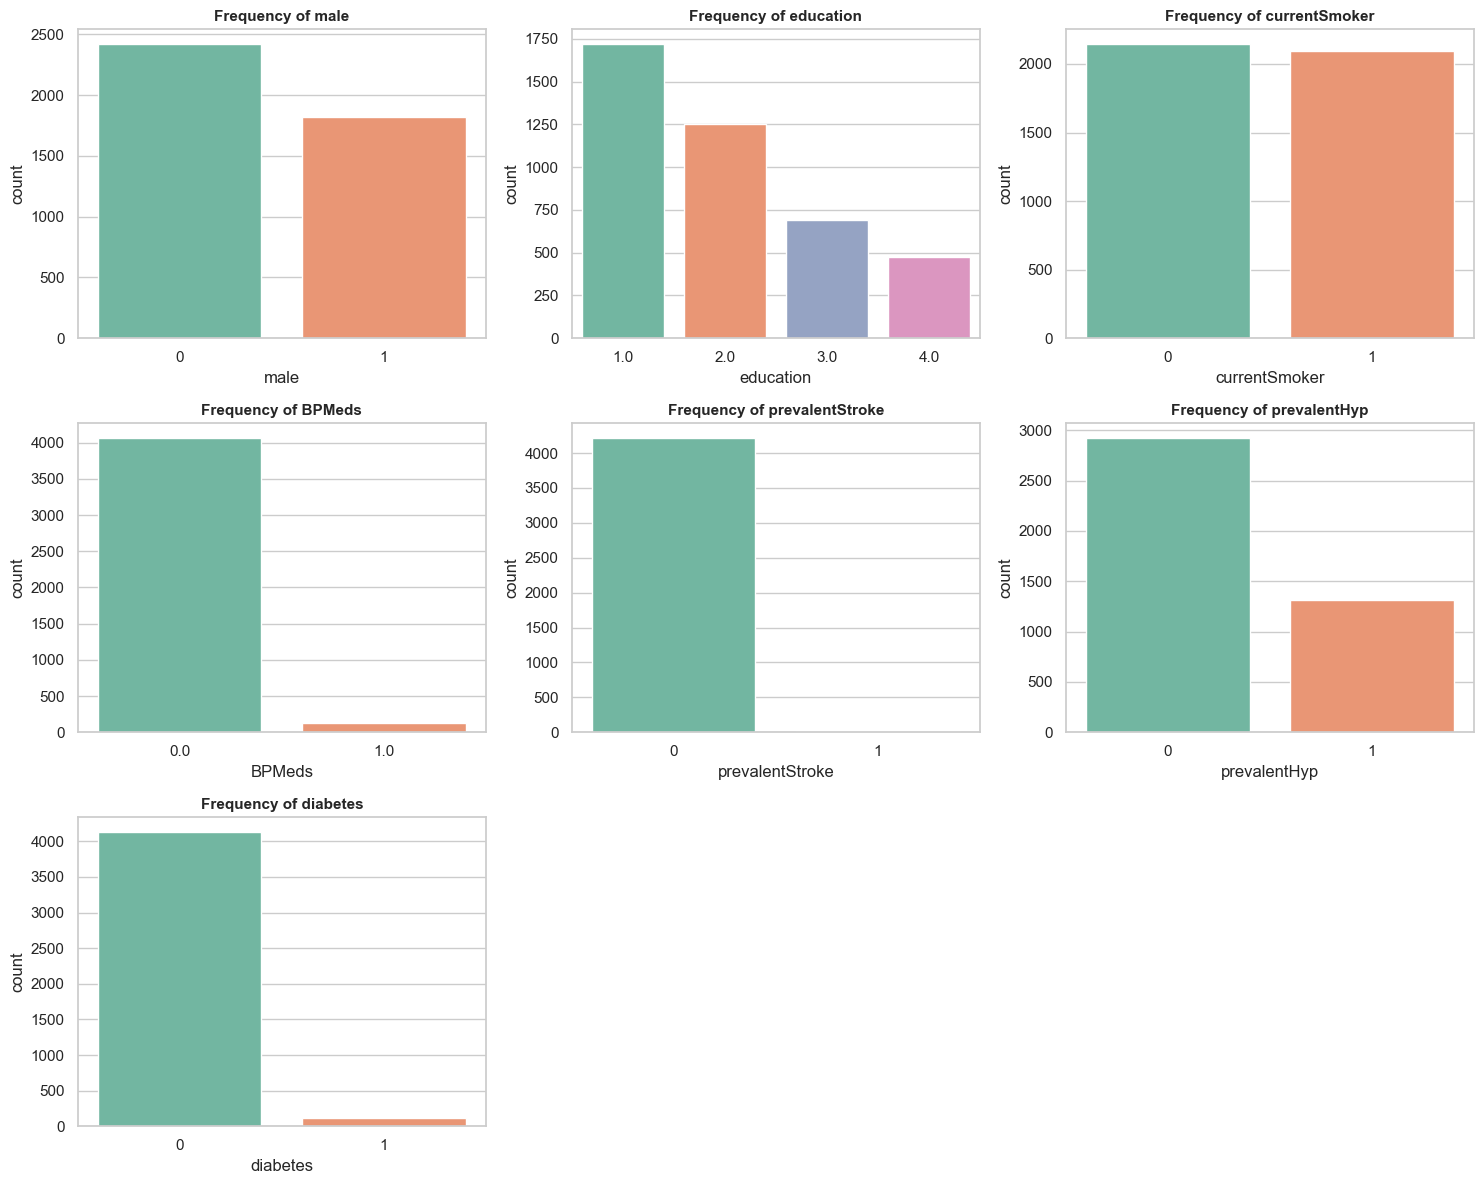

In [8]:
# Select categorical and binary discrete features
cat_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

# Plot frequency bar charts for categorical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'Frequency of {col}', fontsize=11, fontweight='bold')

# Hide remaining unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.4 Bivariate Analysis: Continuous Features vs TenYearCHD

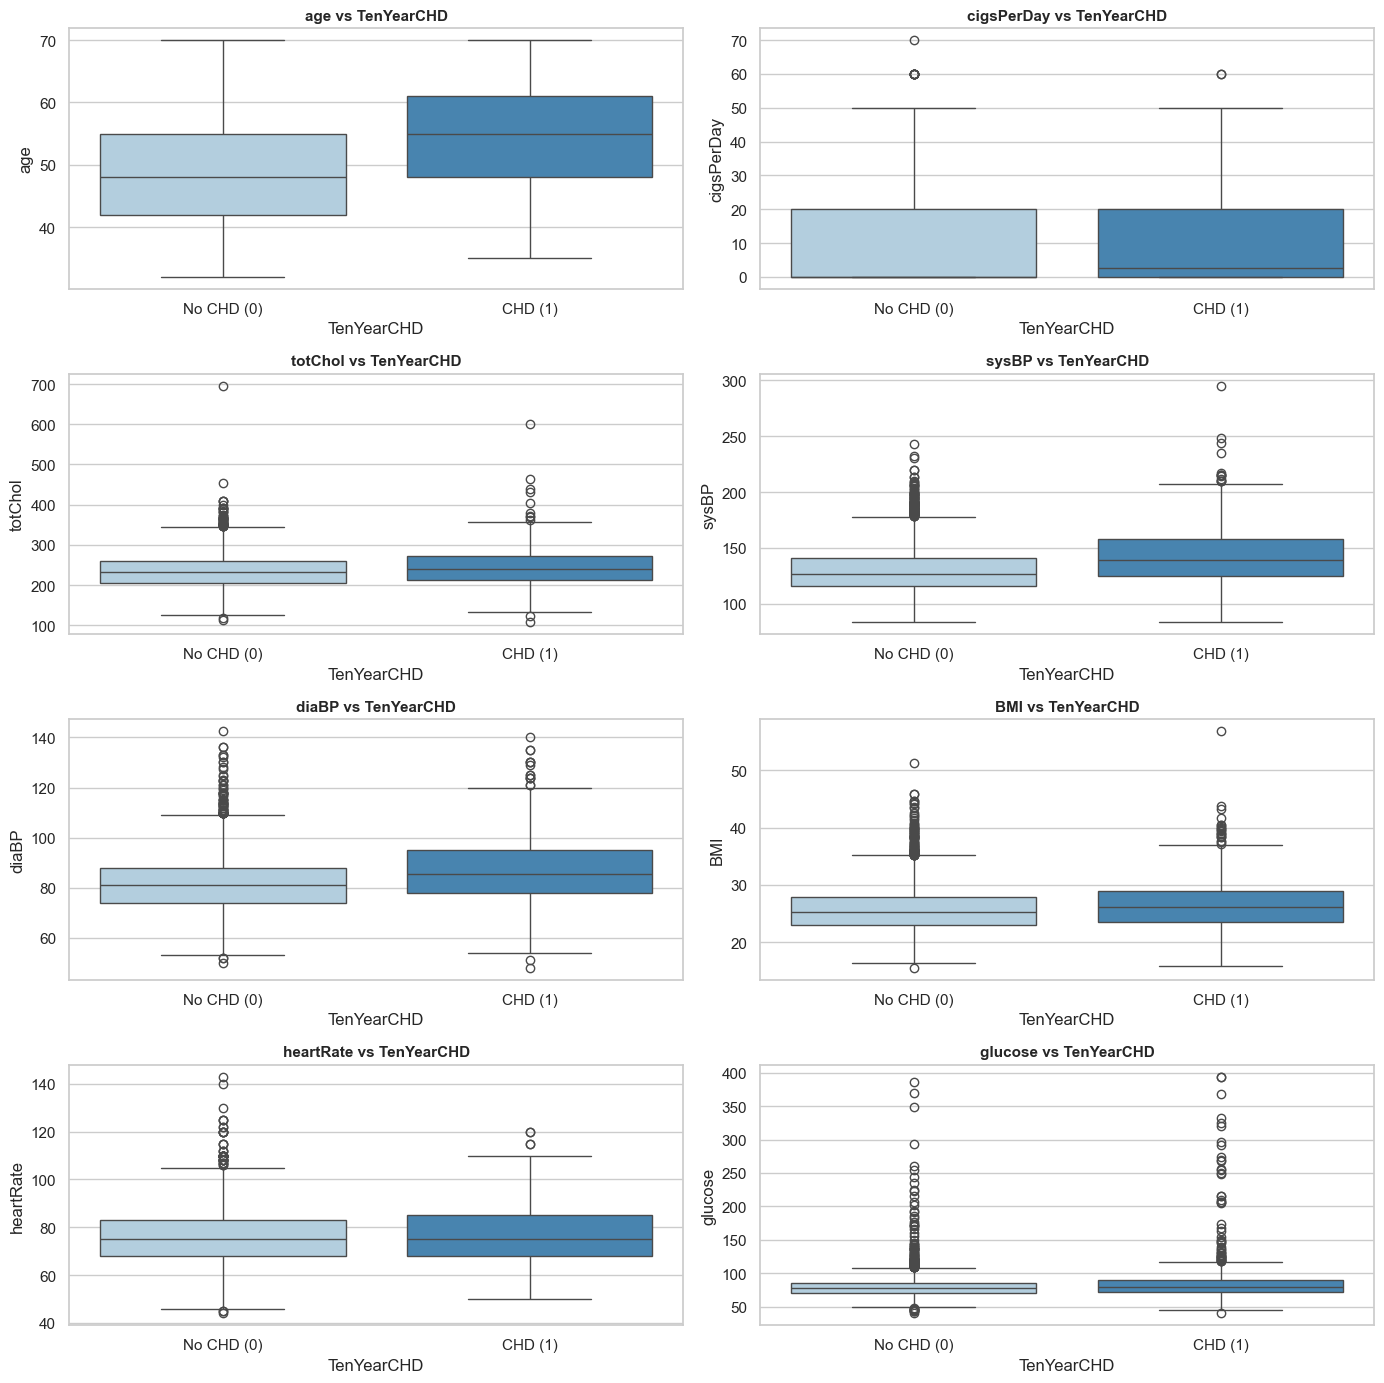

In [9]:
# Plot boxplots comparing continuous features across TenYearCHD target classes
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='TenYearCHD', y=col, hue='TenYearCHD', palette='Blues', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} vs TenYearCHD', fontsize=11, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No CHD (0)', 'CHD (1)'])

plt.tight_layout()
plt.show()

### 3.5 Bivariate Analysis: Categorical Features vs TenYearCHD

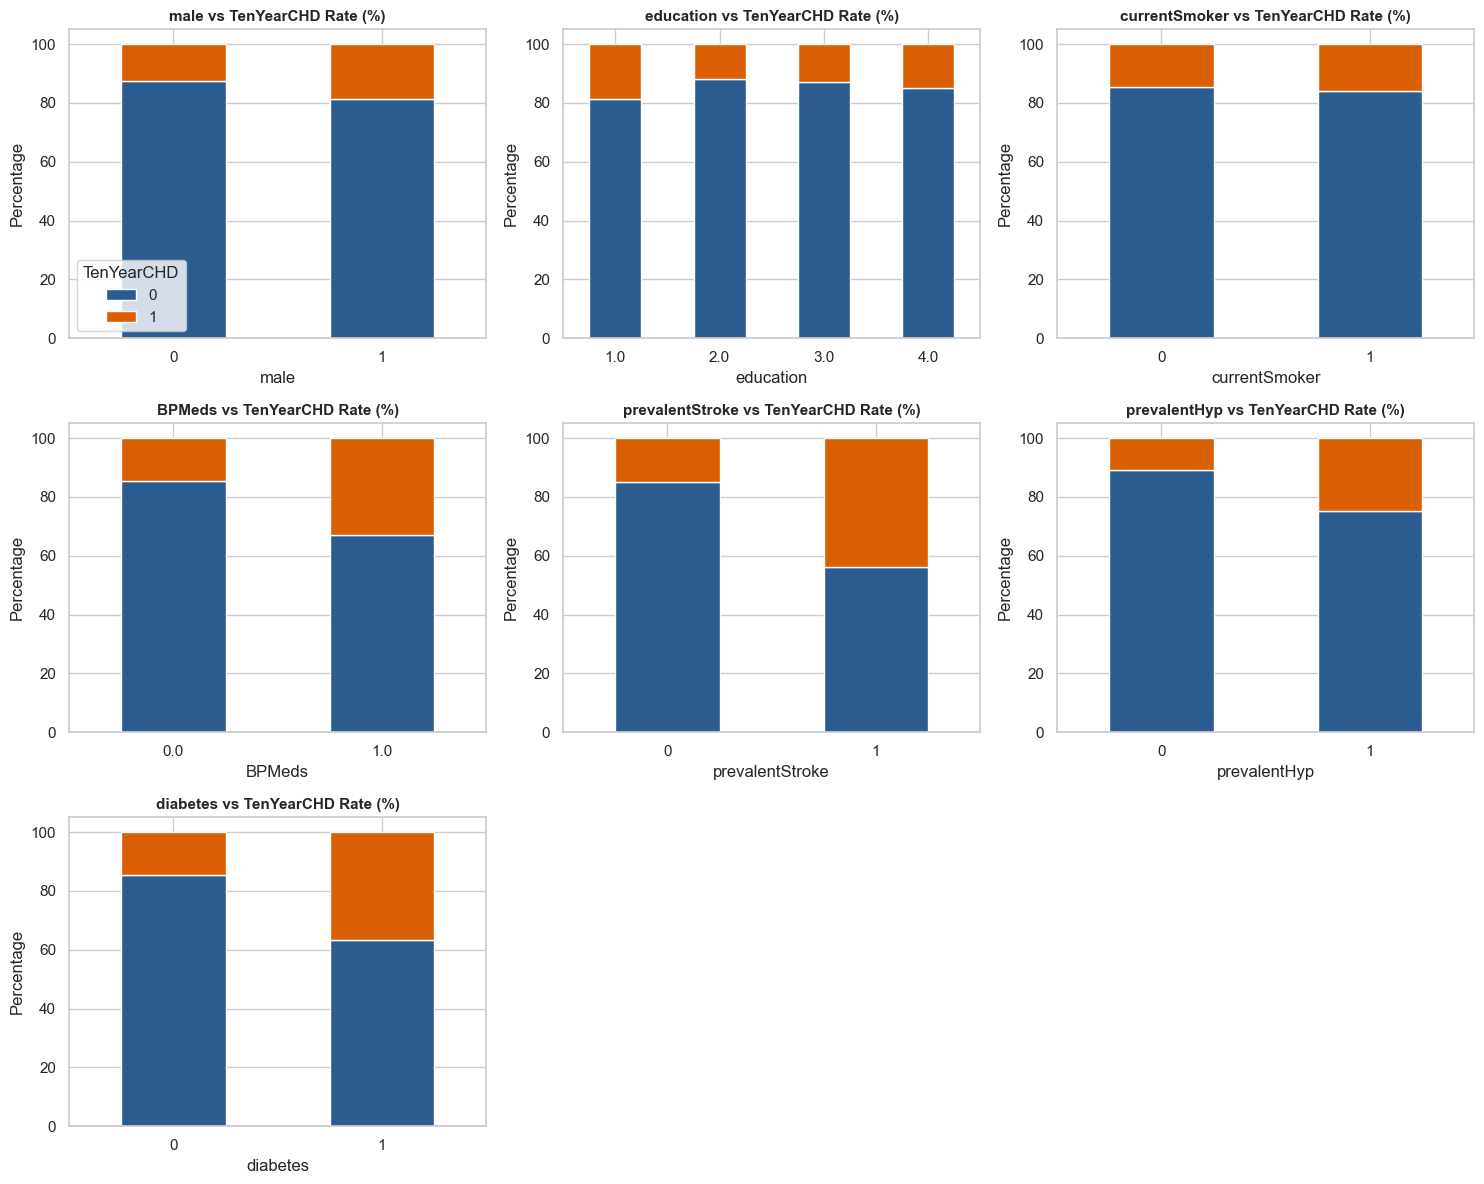

In [10]:
# Plot stacked bar charts showing proportion of TenYearCHD for categorical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross_tab = pd.crosstab(df[col], df['TenYearCHD'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, color=['#2b5c8f', '#d95f02'], ax=axes[i], legend=(i == 0))
    axes[i].set_title(f'{col} vs TenYearCHD Rate (%)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=0)

# Hide remaining unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap & Missing Value Audit

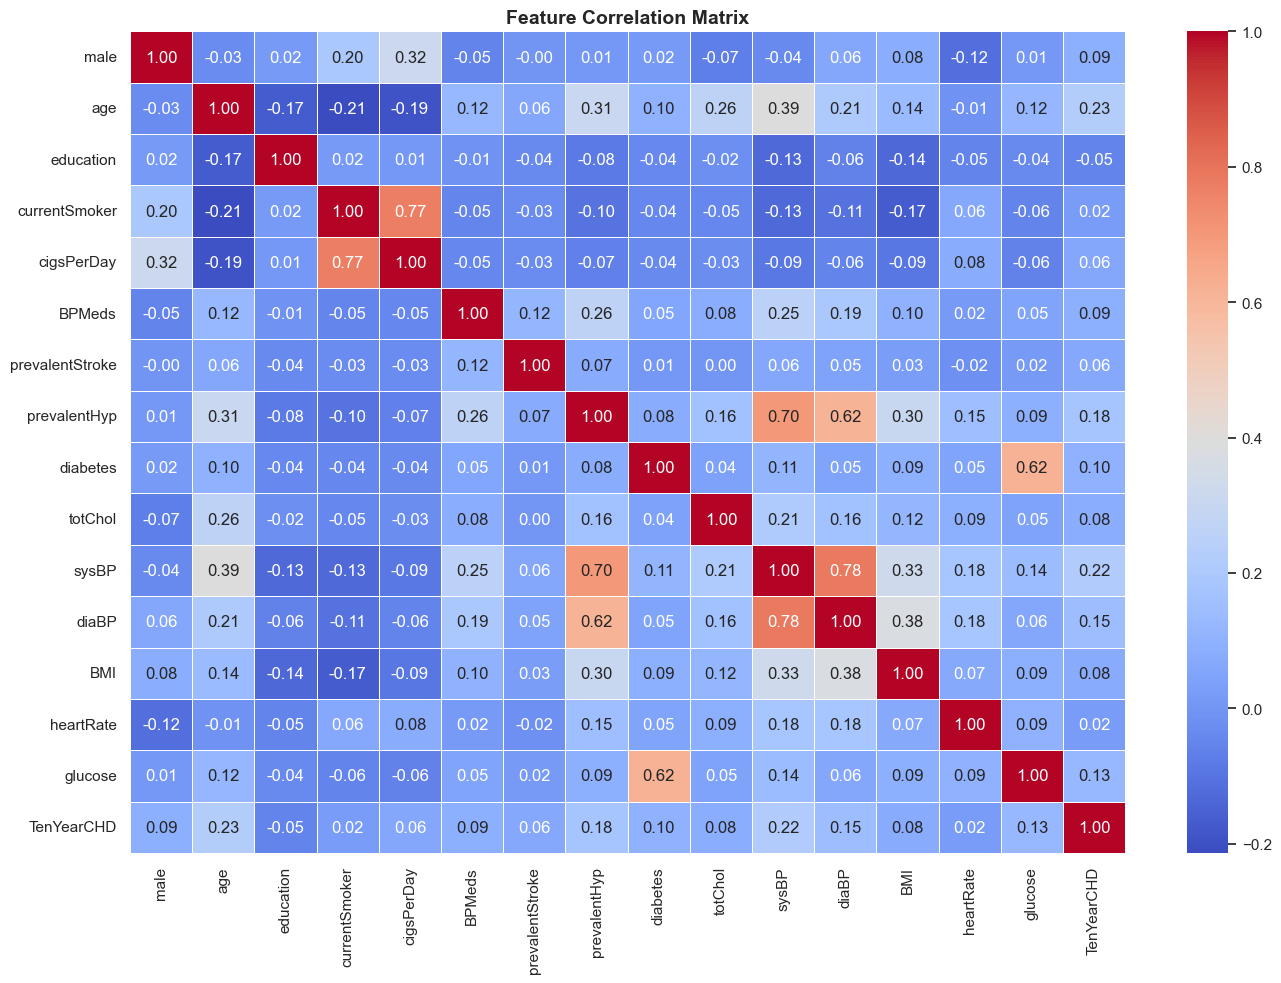

In [11]:
# Plot annotated correlation heatmap matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Audit missing values per column
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print("Missing Values Breakdown:")
print(missing_summary)

# Audit duplicate rows count
print("\nDuplicate Rows Count:", df.duplicated().sum())

Missing Values Breakdown:
            Missing Count  Missing Percentage (%)
glucose               388                    9.15
education             105                    2.48
BPMeds                 53                    1.25
totChol                50                    1.18
cigsPerDay             29                    0.68
BMI                    19                    0.45
heartRate               1                    0.02

Duplicate Rows Count: 0


## 4. Data Preprocessing & Pipeline Preparation

In [13]:
# Copy dataframe for clean data processing
df_clean = df.copy()

# Fix domain inconsistency for non-smokers cigsPerDay
df_clean.loc[df_clean['currentSmoker'] == 0, 'cigsPerDay'] = 0

# Impute categorical missing features using mode
for col in ['education', 'BPMeds']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Impute continuous missing features using median
for col in ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Verify missing values elimination
print("Total Missing Values Remaining:", df_clean.isnull().sum().sum())

Total Missing Values Remaining: 0


In [14]:
# One-hot encode categorical feature education
df_clean = pd.get_dummies(df_clean, columns=['education'], drop_first=True, dtype=int)

# Normalize continuous numerical features with StandardScaler
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
scaler = StandardScaler()
df_clean[continuous_cols] = scaler.fit_transform(df_clean[continuous_cols])

# Display sample of preprocessed dataframe
df_clean.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,education_2.0,education_3.0,education_4.0
0,1,-1.234283,0,-0.751412,0.0,0,0,0,-0.940086,-1.196267,-1.083027,0.287693,0.342792,-0.201287,0,0,0,1
1,0,-0.417664,0,-0.751412,0.0,0,0,0,0.300797,-0.515399,-0.159355,0.720094,1.590451,-0.245036,0,1,0,0
2,1,-0.184345,1,0.928784,0.0,0,0,0,0.187990,-0.220356,-0.243325,-0.112769,-0.073094,-0.507530,0,0,0,0
3,0,1.332233,1,1.768882,0.0,0,1,0,-0.263241,0.800946,1.016227,0.683242,-0.904866,0.936188,1,0,1,0
4,0,-0.417664,1,1.180813,0.0,0,0,0,1.090450,-0.106878,0.092555,-0.663098,0.758678,0.148705,0,0,1,0


In [15]:
# Separate features X and target label y
X = df_clean.drop(columns=['TenYearCHD'])
y = df_clean['TenYearCHD']

# Split data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Output dataset split dimensions
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("\nTrain Class Proportions:\n", y_train.value_counts(normalize=True).round(4))
print("\nTest Class Proportions:\n", y_test.value_counts(normalize=True).round(4))

X_train Shape: (3392, 17)
X_test Shape: (848, 17)

Train Class Proportions:
 TenYearCHD
0    0.8482
1    0.1518
Name: proportion, dtype: float64

Test Class Proportions:
 TenYearCHD
0    0.8479
1    0.1521
Name: proportion, dtype: float64


## 5. Machine Learning Models Training & Benchmarking

In [16]:
# Define dictionary of machine learning classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Support Vector Classifier': SVC(probability=True, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
}

# Evaluate all models and collect metrics
results_list = []

for name, model in models.items():
    # Fit model on training dataset
    model.fit(X_train, y_train)
    
    # Predict labels and probabilities on test dataset
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    # Store performance metrics dictionary
    results_list.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc_score, 4)
    })

# Print confirmation message
print("All machine learning models successfully trained and evaluated.")

All machine learning models successfully trained and evaluated.


## 6. Performance Summary Table & Visual Comparison

In [17]:
# Construct summary DataFrame sorted by ROC-AUC score
results_df = pd.DataFrame(results_list).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

# Display summary table of model performance
print("Machine Learning Models Performance Summary:")
print(results_df.to_string(index=False))

Machine Learning Models Performance Summary:
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Logistic Regression    0.6686     0.2532  0.6047    0.3570   0.6983
                 AdaBoost    0.8502     0.6250  0.0388    0.0730   0.6818
              Naive Bayes    0.8090     0.2676  0.1473    0.1900   0.6723
        Gradient Boosting    0.8361     0.3438  0.0853    0.1366   0.6644
Support Vector Classifier    0.6686     0.2343  0.5194    0.3229   0.6633
              Extra Trees    0.8491     0.5556  0.0388    0.0725   0.6382
            Random Forest    0.8479     0.5000  0.0233    0.0444   0.6283
                 LightGBM    0.7417     0.2256  0.2868    0.2526   0.6048
                  XGBoost    0.7689     0.1869  0.1550    0.1695   0.5795
            Decision Tree    0.7736     0.2397  0.2248    0.2320   0.5484
      K-Nearest Neighbors    0.8420     0.4000  0.0775    0.1299   0.5437


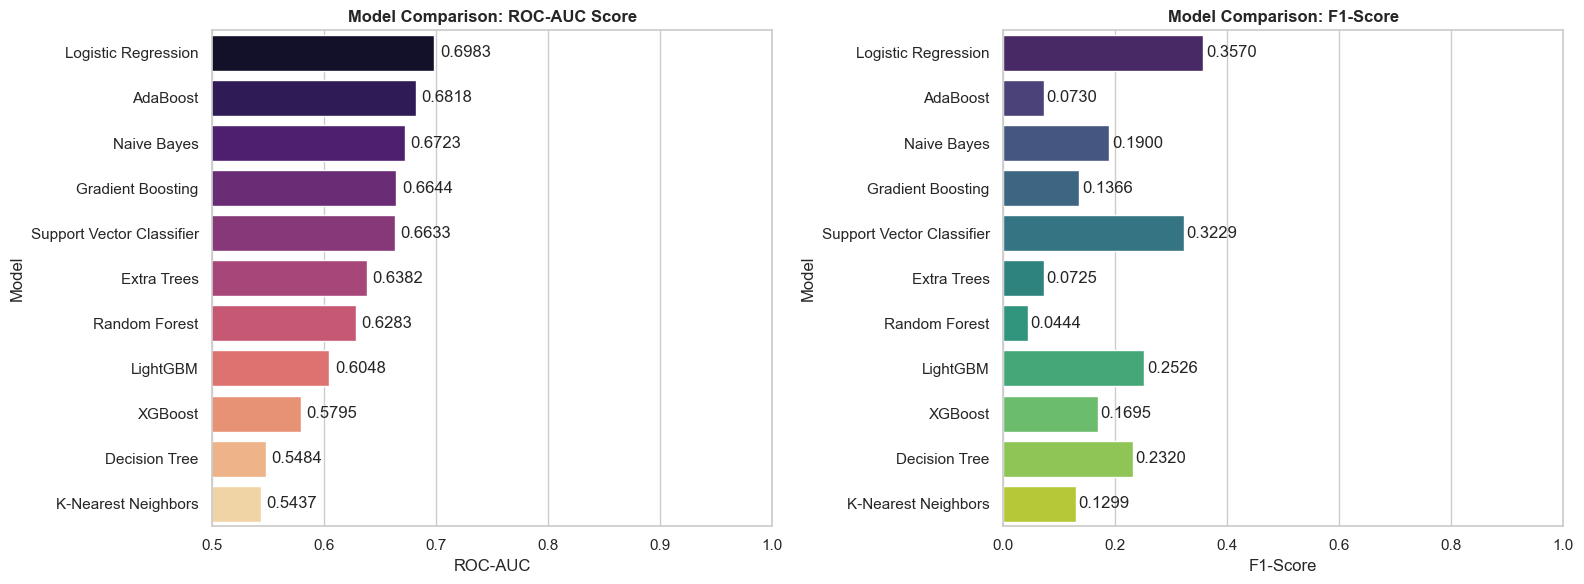

In [18]:
# Plot comparative bar charts for ROC-AUC and F1-Score across models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=results_df, x='ROC-AUC', y='Model', palette='magma', ax=axes[0])
axes[0].set_title('Model Comparison: ROC-AUC Score', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.4f}', (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.), ha='left', va='center')

sns.barplot(data=results_df, x='F1-Score', y='Model', palette='viridis', ax=axes[1])
axes[1].set_title('Model Comparison: F1-Score', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.4f}', (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.), ha='left', va='center')

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning for Best Model

In [19]:
# Select top candidate model for hyperparameter tuning (Random Forest Classifier)
print("Initiating Hyperparameter Tuning for Random Forest Classifier...")

# Define focused hyperparameter grid for efficient tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize Stratified K-Fold cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform Grid Search CV with ROC-AUC scoring metric
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

# Output best hyperparameters and best CV score
print("\nBest Hyperparameters Found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

Initiating Hyperparameter Tuning for Random Forest Classifier...

Best Hyperparameters Found:
  max_depth: 6
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100

Best Cross-Validation ROC-AUC Score: 0.7196


## 8. Best Model Evaluation & Feature Importance Analysis

In [20]:
# Extract best tuned model estimator
best_model = grid_search.best_estimator_

# Predict labels and probabilities on test dataset using best model
y_best_pred = best_model.predict(X_test)
y_best_proba = best_model.predict_proba(X_test)[:, 1]

# Output evaluation metrics for tuned best model
best_acc = accuracy_score(y_test, y_best_pred)
best_prec = precision_score(y_test, y_best_pred)
best_rec = recall_score(y_test, y_best_pred)
best_f1 = f1_score(y_test, y_best_pred)
best_auc = roc_auc_score(y_test, y_best_proba)

print("Tuned Best Model (Random Forest) Test Performance:")
print(f"  Accuracy:  {best_acc:.4f}")
print(f"  Precision: {best_prec:.4f}")
print(f"  Recall:    {best_rec:.4f}")
print(f"  F1-Score:  {best_f1:.4f}")
print(f"  ROC-AUC:   {best_auc:.4f}")

# Display classification report
print("\nClassification Report:\n", classification_report(y_test, y_best_pred, target_names=['No CHD (0)', 'CHD (1)']))

Tuned Best Model (Random Forest) Test Performance:
  Accuracy:  0.7087
  Precision: 0.2542
  Recall:    0.4729
  F1-Score:  0.3306
  ROC-AUC:   0.6734

Classification Report:
               precision    recall  f1-score   support

  No CHD (0)       0.89      0.75      0.81       719
     CHD (1)       0.25      0.47      0.33       129

    accuracy                           0.71       848
   macro avg       0.57      0.61      0.57       848
weighted avg       0.79      0.71      0.74       848



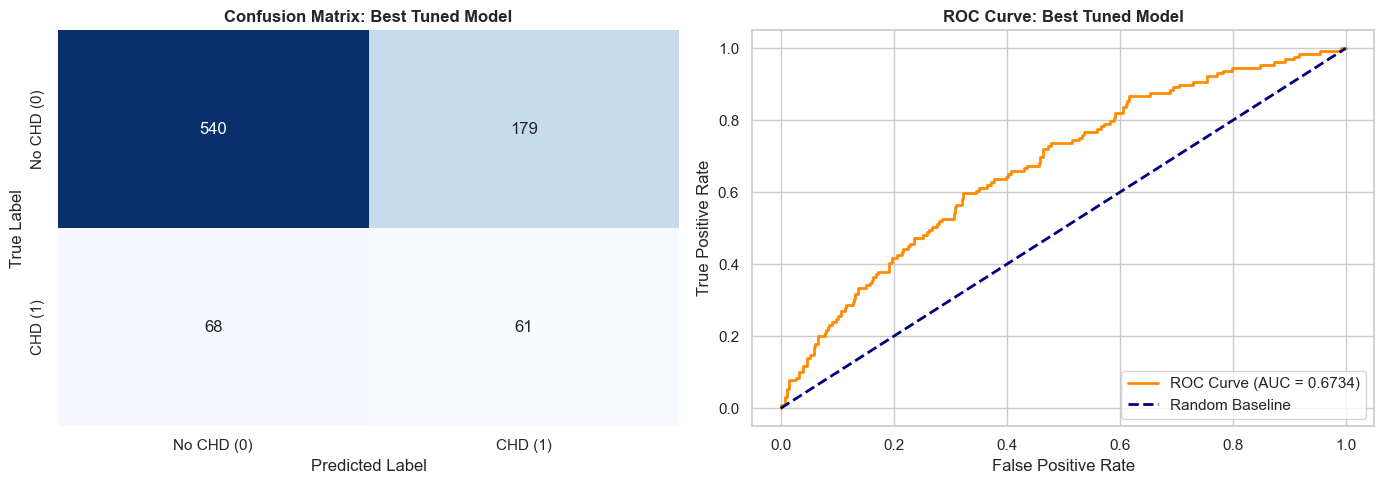

In [21]:
# Plot Confusion Matrix and ROC Curve for tuned best model
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix heatmap
cm = confusion_matrix(y_test, y_best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['No CHD (0)', 'CHD (1)'],
            yticklabels=['No CHD (0)', 'CHD (1)'])
ax[0].set_title('Confusion Matrix: Best Tuned Model', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_best_proba)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {best_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline')
ax[1].set_title('ROC Curve: Best Tuned Model', fontsize=12, fontweight='bold')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

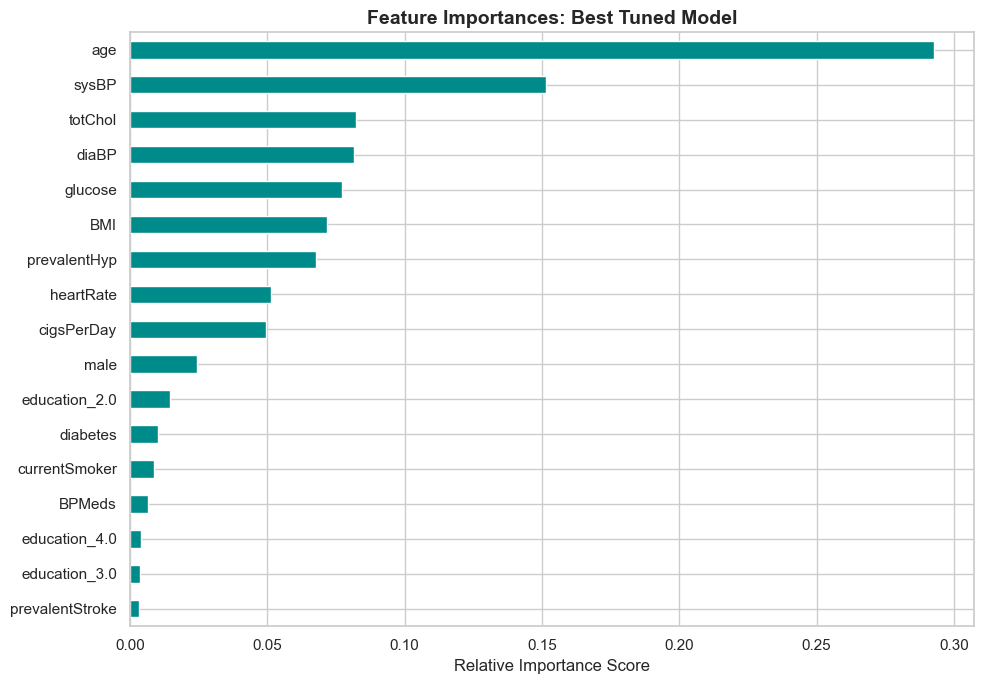

In [22]:
# Extract and plot feature importances of best tuned model
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feature_importances.plot(kind='barh', color='darkcyan')
plt.title('Feature Importances: Best Tuned Model', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

## 9. End-to-End Prediction Pipeline & Sample Patient Risk Inference

In [22]:
# Define custom inference function for predicting patient CHD risk
def predict_patient_chd_risk(patient_data, scaler_object, feature_columns, model_object):
    # Convert input patient data dictionary to DataFrame
    df_patient = pd.DataFrame([patient_data])
    
    # Fix smoker cigsPerDay inconsistency
    if df_patient.loc[0, 'currentSmoker'] == 0:
        df_patient.loc[0, 'cigsPerDay'] = 0
        
    # One-hot encode education columns if present
    for edu_val in [2.0, 3.0, 4.0]:
        col_name = f'education_{edu_val}'
        df_patient[col_name] = 1 if df_patient.loc[0, 'education'] == edu_val else 0
        
    # Scale continuous numerical features using fitted scaler
    cont_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
    df_patient[cont_features] = scaler_object.transform(df_patient[cont_features])
    
    # Ensure column alignment with training dataset features
    df_patient_processed = df_patient.reindex(columns=feature_columns, fill_value=0)
    
    # Predict CHD probability and class label
    chd_probability = model_object.predict_proba(df_patient_processed)[0, 1]
    chd_prediction = model_object.predict(df_patient_processed)[0]
    
    return chd_prediction, chd_probability

# Define sample patient profile 1 (Low Risk Profile)
sample_patient_low_risk = {
    'male': 0, 'age': 38, 'education': 3.0, 'currentSmoker': 0, 'cigsPerDay': 0,
    'BPMeds': 0.0, 'prevalentStroke': 0, 'prevalentHyp': 0, 'diabetes': 0,
    'totChol': 180.0, 'sysBP': 115.0, 'diaBP': 75.0, 'BMI': 22.5,
    'heartRate': 68.0, 'glucose': 80.0
}

# Define sample patient profile 2 (High Risk Profile)
sample_patient_high_risk = {
    'male': 1, 'age': 62, 'education': 1.0, 'currentSmoker': 1, 'cigsPerDay': 25,
    'BPMeds': 1.0, 'prevalentStroke': 0, 'prevalentHyp': 1, 'diabetes': 1,
    'totChol': 295.0, 'sysBP': 165.0, 'diaBP': 105.0, 'BMI': 31.2,
    'heartRate': 88.0, 'glucose': 175.0
}

# Predict risk for sample patient 1
pred_low, proba_low = predict_patient_chd_risk(sample_patient_low_risk, scaler, X.columns, best_model)
print("Sample Patient 1 (Low Risk Profile) Results:")
print(f"  Predicted Class: {pred_low} ({'High CHD Risk' if pred_low == 1 else 'Low CHD Risk'})")
print(f"  Estimated 10-Year CHD Probability: {proba_low * 100:.2f}%")

# Predict risk for sample patient 2
pred_high, proba_high = predict_patient_chd_risk(sample_patient_high_risk, scaler, X.columns, best_model)
print("\nSample Patient 2 (High Risk Profile) Results:")
print(f"  Predicted Class: {pred_high} ({'High CHD Risk' if pred_high == 1 else 'Low CHD Risk'})")
print(f"  Estimated 10-Year CHD Probability: {proba_high * 100:.2f}%")

Sample Patient 1 (Low Risk Profile) Results:
  Predicted Class: 0 (Low CHD Risk)
  Estimated 10-Year CHD Probability: 12.39%

Sample Patient 2 (High Risk Profile) Results:
  Predicted Class: 1 (High CHD Risk)
  Estimated 10-Year CHD Probability: 73.38%
